Image loaded successfully


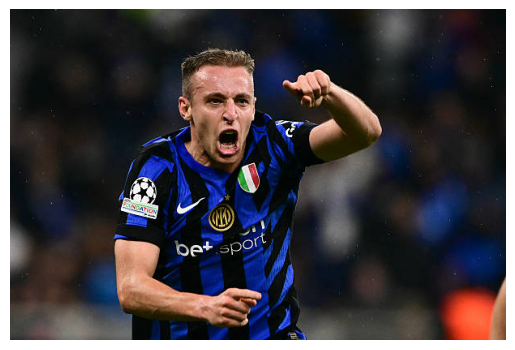

In [ ]:
import cv2
import matplotlib.pyplot as plt

# 1. Charger l'image
image = cv2.imread("frattesi.jpg")

if image is None:
  print("Error loading image")
else:
  print("Image loaded successfully")

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image_rgb)
plt.axis("off")
plt.show()

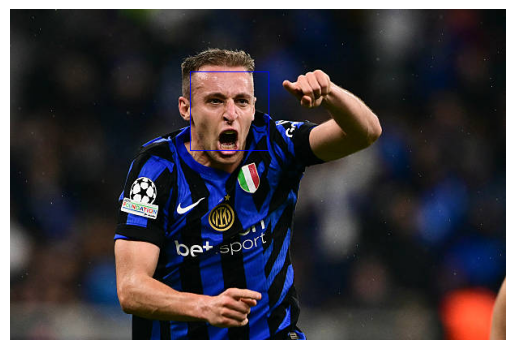

In [ ]:
# Charger le modèle Haar Cascade
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades +
                                     'haarcascade_frontalface_default.xml')

# Convertir l'image en gris
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Détecter les visages
faces = face_cascade.detectMultiScale(gray,1.3, 5)

# Dessiner rectangles
for (x, y, w, h) in faces:
    cv2.rectangle(image_rgb, (x, y), (x+w, y+h), (0,0,255))

# Afficher
plt.imshow(image_rgb)
plt.axis("off")
plt.show()

In [ ]:
import numpy as np

faces_processed = []

for (x, y, w, h) in faces:
    face = gray[y:y+h, x:x+w]

    # redimensionner
    face_resized = cv2.resize(face, (100,100))

    # normaliser
    face_normalized = face_resized / 255.0

    faces_processed.append(face_normalized)

faces_processed = np.array(faces_processed)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(100,100,1)))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dense(1, activation='sigmoid'))   # classification binaire

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 98, 98, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 49, 49, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 47, 47, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 33856)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     4,333,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,352,641 (16.60 MB)

 Trainable params: 4,352,641 (16.60 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from sklearn.model_selection import train_test_split
import numpy as np

X = faces_processed.reshape(-1,100,100,1)
y = np.array([0]*len(X))   # exemple label, ensure y is a numpy array

# Check number of samples
if len(X) > 1:
    # division train/test
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42 # Added random_state for reproducibility
    )
    print(f"Dataset split into {len(X_train)} training samples and {len(X_test)} testing samples.")

    # entraînement
    history = model.fit(
        X_train, y_train,
        epochs=10,
        validation_data=(X_test, y_test)
    )

    # évaluation
    loss, accuracy = model.evaluate(X_test, y_test)
    print("Accuracy:", accuracy)

elif len(X) == 1:
    X_train = X
    y_train = y
    # Create empty arrays for X_test and y_test with correct shapes and dtypes
    X_test = np.array([], dtype=X.dtype).reshape(0, *X.shape[1:])
    y_test = np.array([], dtype=y.dtype)

    print("Only one sample detected. Training on this single sample. No meaningful test set can be created.")

    # entraînement without validation_data
    history = model.fit(
        X_train, y_train,
        epochs=10
    )

    # évaluation (no test data available)
    print("No test data available for evaluation.")

else: # len(X) == 0
    print("No samples detected. Skipping training and evaluation.")

Only one sample detected. Training on this single sample. No meaningful test set can be created.
Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.0000e+00 - loss: 0.7396
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 1.0000 - loss: 0.0242
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 1.0000 - loss: 6.5383e-04
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - accuracy: 1.0000 - loss: 1.8160e-05
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 1.0000 - loss: 6.2342e-07
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 1.0000 - loss: 2.5987e-08
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 1.0000 - loss: 1.2881e-09
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 1.0000 - loss: 7.6000e-11
Epoch 9/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 1.0000 - loss: 5.3342e-12
Epoch 10/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 1.0000 - loss: 4.4319e-13
No test data available for evalu

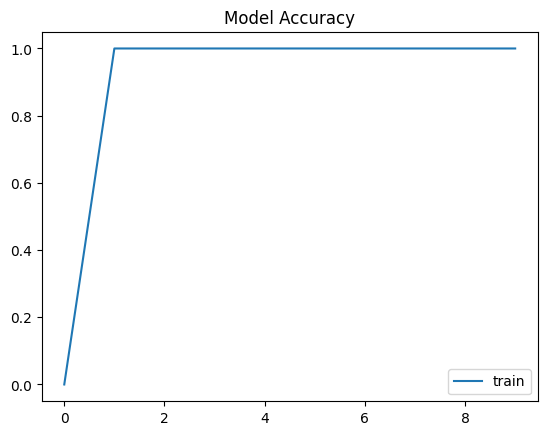

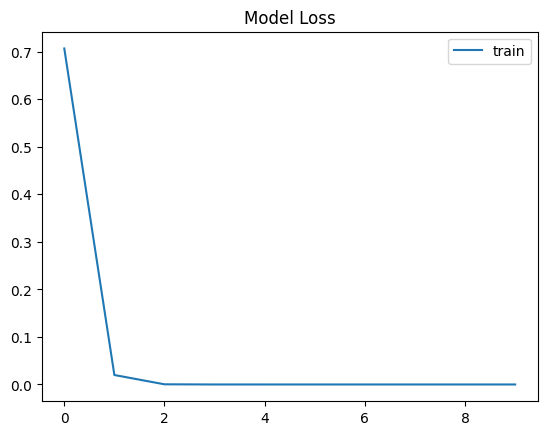

In [ ]:
plt.plot(history.history['accuracy'])
plt.title('Model Accuracy')
plt.legend(['train','test'])
plt.show()

plt.plot(history.history['loss'])
plt.title('Model Loss')
plt.legend(['train','test'])
plt.show()

In [ ]:
new_image = cv2.imread("test.jpg")
gray = cv2.cvtColor(new_image, cv2.COLOR_BGR2GRAY)

faces = face_cascade.detectMultiScale(gray,1.3,5)

for (x,y,w,h) in faces:
    face = gray[y:y+h, x:x+w]
    face = cv2.resize(face,(100,100))
    face = face/255.0
    face = face.reshape(1,100,100,1)

    prediction = model.predict(face)

    print("Prediction:", prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
Prediction: [[4.0204856e-16]]
